# Lecture 3 — Nonlinear Hypothesis Classes

**CMU 10-414/714, Deep Learning Systems**
Companion notebook · Sangram Lembe

Two of the three ingredients do not change from lecture 2. The loss is still cross-entropy, the
optimizer is still SGD. Only the **hypothesis class** changes, and this notebook is about why it
has to.

Four things get demonstrated rather than asserted:

1. a linear model fails on data that curves, and the failure is in the hypothesis class
2. stacking two linear layers produces exactly one linear layer — verified numerically
3. a fixed, *untrained* random feature map already fixes the problem, which says the power is
   not simply in having a nonlinearity
4. the universal approximation theorem, built explicitly from ReLUs, with its cost measured

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split

np.random.seed(0)

def softmax_rows(logits):
    Z = np.exp(logits - logits.max(1, keepdims=True))
    return Z / Z.sum(1, keepdims=True)

def one_hot(y, k):
    I = np.zeros((y.size, k)); I[np.arange(y.size), y] = 1
    return I

def train_linear(Xtr, ytr, Xte, yte, k, lr=0.2, B=64, epochs=400, bias=True, seed=0):
    """Softmax regression. Returns (train error, test error)."""
    np.random.seed(seed)                       # same shuffling every call
    A, C = (np.c_[Xtr, np.ones(len(Xtr))], np.c_[Xte, np.ones(len(Xte))]) if bias \
           else (Xtr, Xte)
    theta = np.zeros((A.shape[1], k))
    for _ in range(epochs):
        order = np.random.permutation(len(A))
        for i in range(0, len(A), B):
            idx = order[i:i+B]
            Xb, yb = A[idx], ytr[idx]
            theta -= lr * (Xb.T @ (softmax_rows(Xb @ theta) - one_hot(yb, k)) / yb.size)
    err = lambda P, q: float((np.argmax(P @ theta, 1) != q).mean())
    return err(A, ytr), err(C, yte)

## 1. Where a linear model gives up

A linear model scores each class with $\theta^{\mathsf{T}}x$ and predicts the largest, which
carves the input space into $k$ linear regions. Arrange the data as a centre blob with two
concentric rings around it and no set of linear directions can separate the three.

The failure is in the hypothesis class, not the optimizer — more training cannot help.

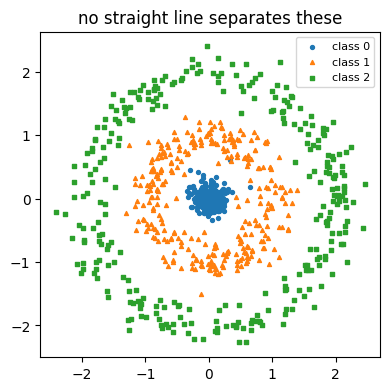

linear model on raw (x1, x2):  train err 0.6700   test err 0.6989


In [2]:
def make_rings(n_per=300, radii=(0.0, 1.0, 2.0), noise=0.18, seed=0):
    """Three classes: a central blob and two concentric annuli."""
    rng = np.random.default_rng(seed)
    Xs, ys = [], []
    for c, r in enumerate(radii):
        ang = rng.uniform(0, 2*np.pi, n_per)
        rad = r + rng.normal(0, noise, n_per)
        Xs.append(np.c_[rad*np.cos(ang), rad*np.sin(ang)])
        ys.append(np.full(n_per, c))
    return np.vstack(Xs), np.concatenate(ys)

Xr_tr, yr_tr = make_rings(seed=0)     # training set
Xr_te, yr_te = make_rings(seed=1)     # a fresh sample for testing

plt.figure(figsize=(4, 4))
for c, mk in zip(range(3), "o^s"):
    plt.scatter(*Xr_tr[yr_tr == c].T, s=8, marker=mk, label=f"class {c}")
plt.gca().set_aspect("equal"); plt.legend(fontsize=8)
plt.title("no straight line separates these"); plt.tight_layout(); plt.show()

baseline = train_linear(Xr_tr, yr_tr, Xr_te, yr_te, k=3)
print("linear model on raw (x1, x2):  train err %.4f   test err %.4f" % baseline)

Roughly two thirds wrong on a three-class problem — barely better than guessing.

## 2. The classical fix: change the data, not the classifier

Feed the classifier $\phi(x)$ instead of $x$. For concentric structure the natural feature is
squared distance from the origin, $r^2 = x_1^2 + x_2^2$, which maps the three classes onto three
separated intervals of a line.

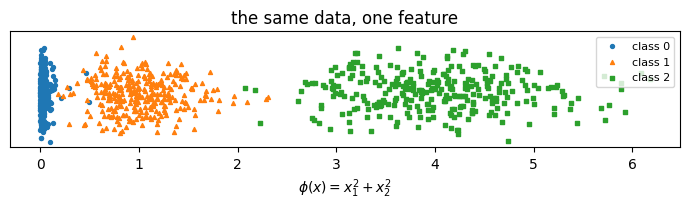

In [3]:
r2 = lambda A: (A**2).sum(1)

plt.figure(figsize=(7, 2.2))
for c, mk in zip(range(3), "o^s"):
    v = r2(Xr_tr)[yr_tr == c]
    plt.scatter(v, np.random.randn(v.size) * 0.03, s=8, marker=mk, label=f"class {c}")
plt.yticks([]); plt.xlabel(r"$\phi(x) = x_1^2 + x_2^2$"); plt.legend(fontsize=8)
plt.title("the same data, one feature"); plt.tight_layout(); plt.show()

The three classes now occupy three clean intervals, and a linear classifier can pick them apart.
It is worth seeing *why*, because the reason is not obvious: each class gets a score
$a_c r^2 + b_c$, a straight line, and the prediction is whichever line is highest. The upper
envelope of $k$ lines is piecewise linear with the lines winning in order of slope — so $k$ lines
give exactly $k$ consecutive intervals, which is precisely the structure of concentric rings.

That argument needs the bias $b_c$. Without it every line passes through the origin, the
intercepts cannot be moved, and the two boundaries cannot be placed independently. The cell below
checks that claim rather than assuming it.

In [4]:
def phi1(A): return np.c_[r2(A)]                      # just r^2
def phi2(A): return np.c_[r2(A), r2(A)**2]            # r^2 and r^4

# Standardise: r^4 reaches ~16 while r^2 reaches ~4, which makes SGD crawl.
mu, sd = phi2(Xr_tr).mean(0), phi2(Xr_tr).std(0)
std2 = lambda A: (phi2(A) - mu) / sd

results = {
    "raw (x1, x2)":            baseline,
    "phi = [r^2], no bias":    train_linear(phi1(Xr_tr), yr_tr, phi1(Xr_te), yr_te, 3, bias=False),
    "phi = [r^2]":             train_linear(phi1(Xr_tr), yr_tr, phi1(Xr_te), yr_te, 3),
    "phi = [r^2, r^4] scaled": train_linear(std2(Xr_tr), yr_tr, std2(Xr_te), yr_te, 3),
}
print(f"{'features':<26}{'train err':>11}{'test err':>11}")
print("-" * 48)
for name, (a, b) in results.items():
    print(f"{name:<26}{a:>11.4f}{b:>11.4f}")

features                    train err   test err
------------------------------------------------
raw (x1, x2)                   0.6700     0.6989
phi = [r^2], no bias           0.6667     0.6667
phi = [r^2]                    0.0144     0.0056
phi = [r^2, r^4] scaled        0.0133     0.0067


Without the bias the single feature is useless; with it, error drops from the raw baseline to
under 1% — and the classifier was never touched. Only the representation changed.

That works when you know what matters about your data. For raw pixels, audio or language,
nothing tells you. Hence the question the rest of the course answers: can $\phi$ be **learned**?

## 3. The collapse

The obvious first attempt is to make $\phi$ linear too, $\phi(x) = W^{\mathsf{T}}x$. Then

$$h_\theta(x) = \theta^{\mathsf{T}} W^{\mathsf{T}} x = (W\theta)^{\mathsf{T}} x$$

and $W\theta$ is just another matrix. Every member of the two-stage model was already a member of
the one-stage model, so the hypothesis class did not grow by a single function.

In [5]:
digits = load_digits()
X_all, y_all = digits.data / 16.0, digits.target.astype(int)
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.25, random_state=0, stratify=y_all)
m, n = X_train.shape
k = int(y_all.max() + 1)

W1 = np.random.randn(n, 32)      # "feature map"
W2 = np.random.randn(32, k)      # classifier on top

two_stage  = X_train @ W1 @ W2   # the two-layer model
equivalent = W1 @ W2             # collapsed into ONE (n, k) matrix

print("two-layer output shape :", two_stage.shape)
print("collapsed matrix shape :", equivalent.shape)
print("outputs identical      :", np.allclose(two_stage, X_train @ equivalent))

two-layer output shape : (1347, 10)
collapsed matrix shape : (64, 10)
outputs identical      : True


In [6]:
# It does not matter how many layers you stack.
Ws = [np.random.randn(n, 40), np.random.randn(40, 40),
      np.random.randn(40, 40), np.random.randn(40, k)]

deep = X_train
for W in Ws:
    deep = deep @ W

collapsed = Ws[0]
for W in Ws[1:]:
    collapsed = collapsed @ W

print(f"4 stacked linear layers == one {collapsed.shape} matrix :",
      np.allclose(deep, X_train @ collapsed))

4 stacked linear layers == one (64, 10) matrix : True


## 4. The fix, and how small it is

Apply any nonlinear $\sigma$ elementwise and the collapse is blocked, because $\sigma$ does not
commute with matrix multiplication:

$$h_\theta(X) = \sigma(X W_1)\, W_2$$

The choice of $\sigma$ is remarkably unfussy — essentially any non-trivial function works.

In [7]:
def relu(z):    return np.maximum(0, z)
def sigmoid(z): return 1 / (1 + np.exp(-z))

for name, sigma in [("ReLU", relu), ("sigmoid", sigmoid),
                    ("tanh", np.tanh), ("cos", np.cos)]:
    nonlinear = sigma(X_train @ W1) @ W2
    linear    = X_train @ (W1 @ W2)
    print(f"{name:>8}: still collapses to a linear model? {np.allclose(nonlinear, linear)}")

    ReLU: still collapses to a linear model? False
 sigmoid: still collapses to a linear model? False
    tanh: still collapses to a linear model? False
     cos: still collapses to a linear model? False


## 5. The result that should unsettle you

Fill $W$ with Gaussian samples, **never train it**, and set $\sigma = \cos$. Those are *random
Fourier features*. If the power came from *learning* the feature map, this should not work.

Back to the rings, where a linear model was helpless.

In [8]:
def random_fourier(A, W, b):
    """A FIXED feature map. W and b are sampled once and never updated."""
    return np.cos(A @ W + b)

d = 200
Wf = np.random.randn(2, d)                  # fixed random projection
bf = np.random.uniform(0, 2*np.pi, d)       # fixed random phase

rff_tr, rff_te = train_linear(random_fourier(Xr_tr, Wf, bf), yr_tr,
                              random_fourier(Xr_te, Wf, bf), yr_te, k=3)

print(f"{'model on the rings':<34}{'train err':>11}{'test err':>11}")
print("-" * 56)
print(f"{'linear on raw (x1, x2)':<34}{results['raw (x1, x2)'][0]:>11.4f}"
      f"{results['raw (x1, x2)'][1]:>11.4f}")
print(f"{'hand-designed phi = [r^2, r^4]':<34}"
      f"{results['phi = [r^2, r^4] scaled'][0]:>11.4f}"
      f"{results['phi = [r^2, r^4] scaled'][1]:>11.4f}")
print(f"{'random Fourier features (untrained)':<34}{rff_tr:>11.4f}{rff_te:>11.4f}")

model on the rings                  train err   test err
--------------------------------------------------------
linear on raw (x1, x2)                 0.6700     0.6989
hand-designed phi = [r^2, r^4]         0.0133     0.0067
random Fourier features (untrained)     0.0056     0.0033


Random noise as a feature extractor matches a feature designed by someone who knew the answer.
Nothing in that map was learned.

So the nonlinearity alone is not where the power lives — worth remembering when the universal
approximation theorem arrives in section 7.

The size of the win depends on how badly you needed non-linearity. On the rings, where a linear
model was hopeless, random features are the difference between useless and solved. On the 8×8
digits, where a linear model is already decent, the same trick gives a real but far more modest
improvement — there is simply less for the features to fix.

In [9]:
Wd = np.random.randn(n, 300) * 0.6
bd = np.random.uniform(0, 2*np.pi, 300)
raw = train_linear(X_train, y_train, X_test, y_test, k, epochs=60)
rff = train_linear(random_fourier(X_train, Wd, bd), y_train,
                   random_fourier(X_test,  Wd, bd), y_test, k, epochs=60)
print(f"digits, linear on raw pixels        : test err {raw[1]:.4f}")
print(f"digits, linear on random features   : test err {rff[1]:.4f}")

digits, linear on raw pixels        : test err 0.0400
digits, linear on random features   : test err 0.0244


## 6. The two-layer network, and its shapes

What a neural network adds is to stop freezing $W$ and train it alongside $\theta$:

$$h_\theta(X) = \sigma(X W_1)\, W_2, \qquad \theta = \{W_1, W_2\}$$

Shape bookkeeping is the main source of bugs in this course, so assert rather than trust.

In [10]:
def two_layer_forward(X, W1, W2):
    """X: (m, n).  W1: (n, d).  W2: (d, k).  Returns logits (m, k)."""
    Z = relu(X @ W1)      # hidden layer, (m, d)
    return Z @ W2         # logits, (m, k) - no softmax here

d_hidden = 128
A1 = np.random.randn(n, d_hidden) * 0.1
A2 = np.random.randn(d_hidden, k) * 0.1
out = two_layer_forward(X_train, A1, A2)

for name, arr, want in [("X", X_train, (m, n)), ("W1", A1, (n, d_hidden)),
                        ("relu(X W1)", relu(X_train @ A1), (m, d_hidden)),
                        ("W2", A2, (d_hidden, k)), ("output", out, (m, k))]:
    assert arr.shape == want, name
    print(f"{name:>12}: {str(arr.shape):>12}")
print("\nall shapes as expected")

           X:   (1347, 64)
          W1:    (64, 128)
  relu(X W1):  (1347, 128)
          W2:    (128, 10)
      output:   (1347, 10)

all shapes as expected


## 7. Universal approximation, built explicitly

The theorem: for a smooth $f$ on a closed bounded region and any tolerance $\epsilon$ chosen in
advance, some one-hidden-layer network stays within $\epsilon$ everywhere.

The proof is a construction — sample $f$ on a grid, join the samples with a piecewise-linear
spline, and represent that spline exactly with ReLUs. Each unit contributes
$\pm\max(0, w_i x + b_i)$: flat, then a kink, then a ramp. The bias places the kink, the weight
sets the slope after it.

So building the network is arithmetic on slope *changes* — no optimization at all.

In [11]:
def fit_relu_spline(f, lo, hi, n_units):
    """Exact ReLU representation of the linear spline through n_units samples."""
    xs = np.linspace(lo, hi, n_units)
    slopes = np.diff(f(xs)) / np.diff(xs)                 # slope of each segment
    deltas = np.diff(np.concatenate([[0.0], slopes]))     # slope CHANGE at each kink
    return xs[:-1], deltas, f(xs)[0]                      # kinks, weights, constant

def evaluate(x, kinks, deltas, c):
    """One hidden unit per kink. This IS the network: a sum of ReLUs plus a bias."""
    return c + sum(w * np.maximum(0.0, x - t) for t, w in zip(kinks, deltas))

f = lambda x: np.sin(3*x) + 0.4*np.cos(7*x)
grid = np.linspace(0, 2, 4001)

print(f"{'hidden units':>13}{'max error':>13}")
print("-" * 26)
errors = []
for u in (8, 16, 32, 64, 128):
    kinks, deltas, c = fit_relu_spline(f, 0, 2, u)
    e = np.abs(f(grid) - evaluate(grid, kinks, deltas, c)).max()
    errors.append((u, e))
    print(f"{u:>13}{e:>13.5f}")

 hidden units    max error
--------------------------
            8      0.22819
           16      0.05718
           32      0.01373
           64      0.00336
          128      0.00083


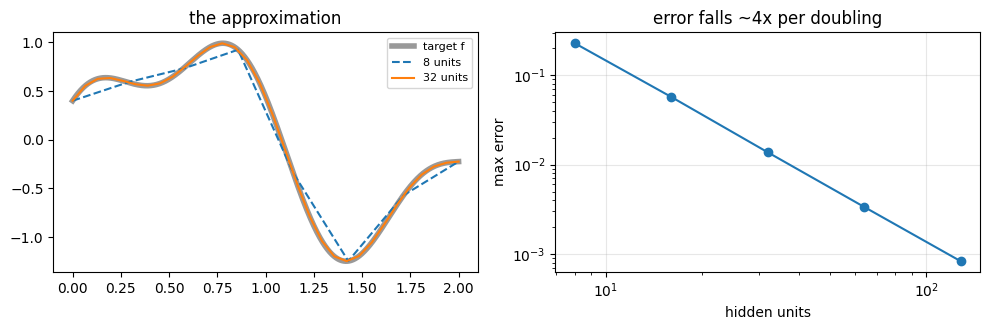

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(10, 3.4))
ax[0].plot(grid, f(grid), color="0.6", lw=4, zorder=0, label="target f")
for u, style in [(8, "--"), (32, "-")]:
    kinks, deltas, c = fit_relu_spline(f, 0, 2, u)
    ax[0].plot(grid, evaluate(grid, kinks, deltas, c), style, lw=1.5, label=f"{u} units")
ax[0].legend(fontsize=8); ax[0].set_title("the approximation")

us, es = zip(*errors)
ax[1].loglog(us, es, "o-")
ax[1].set_xlabel("hidden units"); ax[1].set_ylabel("max error")
ax[1].set_title("error falls ~4x per doubling"); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

Any $\epsilon$ you name is reachable — and the cost is roughly **one hidden unit per sample
point**, with error falling about $4\times$ each time the width doubles. Four times the network
buys one extra decimal place.

In $n$ dimensions the grid is $n$-dimensional, so the count grows exponentially. And step two of
the proof already showed linear splines are universal approximators; so are nearest neighbours,
and nobody builds a field around them.

**Universal approximation is not the reason neural networks work.**

## Summary

- A linear model fails on the rings at 67% error, and no amount of training fixes a hypothesis-class failure.
- A hand-designed $\phi$ drops that below 1% without touching the classifier — but note that separable-by-thresholds is not the same as separable-by-a-linear-score.
- Stacking linear layers is provably pointless: $\theta^{\mathsf{T}}W^{\mathsf{T}}x = (W\theta)^{\mathsf{T}}x$, confirmed numerically.
- Untrained random Fourier features match the hand-designed map, so the power is not in the nonlinearity alone.
- Universal approximation is true, cheaply provable, and expensive in width.

Next: train $W_1$ as well as $W_2$. That needs gradients for both — backpropagation.